# Exploratory Data analysis

This document explores the UCI Student Performance dataset based on secondary school results in Portugal. It consists of vital school data like absences , study time , previous failures , educational support , family support, Grades etc.

In [1]:
#import pandas library
import pandas as pd
import numpy as np

In [2]:
#load data set
dfCsv= pd.read_csv("../data/raw/student-por.csv",
                    sep= ";")
print("CSV File loaded successfully")
dfCsv.head()

CSV File loaded successfully


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
# size of dataset
print(dfCsv.shape)
#colomn headers
dfCsv.info()

(649, 33)
<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  

In [4]:
#any duplicated values?
dupInfo= dfCsv.duplicated().sum()
print(dupInfo)

0


In [5]:
#any null values?
missInfo= dfCsv.isnull().sum()
print(missInfo)

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [6]:
#Descriptive statistics
dfCsv.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [7]:
#fairness analysis, check values for sex
dfCsv['sex'].value_counts()

sex
F    383
M    266
Name: count, dtype: int64

In [8]:
#fairness analysis, check values for school
dfCsv['school'].value_counts()

school
GP    423
MS    226
Name: count, dtype: int64

In [9]:
#remove column first if created already
if "at_risk" in dfCsv.columns:
    dfCsv.drop(columns=["at_risk"], inplace=True)

#insert() to add a column at pos 33 where value is 1 if g3<10, else 0
dfCsv.insert(33, "at_risk", (dfCsv["G3"] < 10).astype(int))

#count how many students at risk/not at risk
dfCsv["at_risk"].value_counts()
#dfCsv.head()

at_risk
0    549
1    100
Name: count, dtype: int64

In [10]:
#give this value as a percentage of no of students
dfCsv["at_risk"].value_counts(normalize=True) * 100

at_risk
0    84.59168
1    15.40832
Name: proportion, dtype: float64

This shows that the dataset is imbalanced as the number of students not at risk are 85% wheras the students at risk are 15%. This means we cannot judge the Machine Learning model using accuracy alone, as it might just predict the majority class and look accurate.

# Figure 1- Distribution of both categories

In [11]:
import kiwisolver
import matplotlib.pyplot as plt

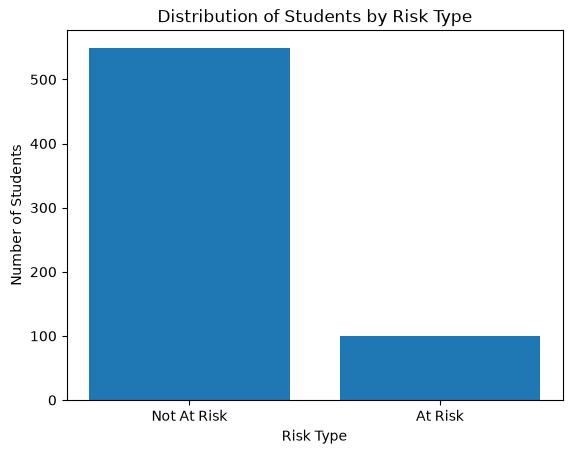

In [12]:
#
riskType = ["Not At Risk", "At Risk"]
studentVariation = [549, 100]

#create barchart
plt.bar(riskType, studentVariation)

#labels and title
plt.xlabel("Risk Type")
plt.ylabel("Number of Students")
plt.title("Distribution of Students by Risk Type")

plt.savefig("../outputs/figures/1-risk_type_distrubution")

plt.show()


# Figure 2- G1 scores


Do students who are eventually at risk have lower G1 grades already (G1 is the first term grades)

In [13]:
#calculate mean G1 for each risk category
g1Avg = dfCsv.groupby("at_risk")["G1"].mean()
g1Avg

at_risk
0    12.058288
1     7.780000
Name: G1, dtype: float64

The At risk average is less than the not risk students. This means the At Risk group scored about 4.28 marks lower in their first-period grade.

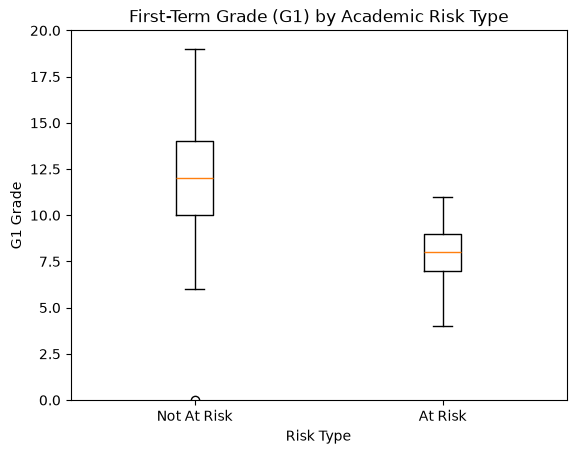

In [14]:
#split G1 data into 2 - risk, no risk - calculate median for each group
dfCsv.groupby("at_risk")["G1"].median()

#grades where student at risk vs not at risk
noRiskG1= dfCsv[dfCsv["at_risk"] ==0]["G1"]
riskG1= dfCsv[dfCsv["at_risk"] ==1]["G1"]


plt.boxplot(
    [noRiskG1, riskG1],
    #2 boxplots, one for each group
    tick_labels=["Not At Risk", "At Risk"]
)

plt.xlabel("Risk Type")
plt.ylabel("G1 Grade")
plt.title("First-Term Grade (G1) by Academic Risk Type")

plt.ylim(0, 20)


plt.savefig("../outputs/figures/2-risk_Type_g1_boxplot.png")

plt.show()


In [15]:
dfCsv.groupby("at_risk")["G1"].median()

at_risk
0    12.0
1     8.0
Name: G1, dtype: float64

# Figure 3- G2 Scores

Are second-period grades different between students who eventually become At Risk and those who do not?

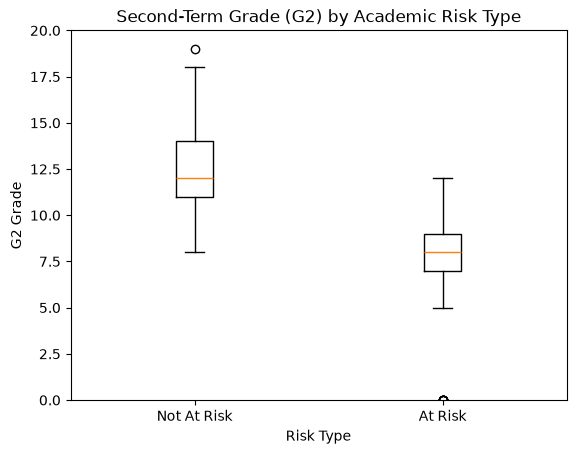

In [16]:
#split G2 data into 2 - risk, no risk - calculate median for each group
dfCsv.groupby("at_risk")["G2"].median()

#grades where student at risk vs not at risk
noRiskG2= dfCsv[dfCsv["at_risk"] ==0]["G2"]
riskG2= dfCsv[dfCsv["at_risk"] ==1]["G2"]


plt.boxplot(
    [noRiskG2, riskG2],
    #2 boxplots, one for each group
    tick_labels=["Not At Risk", "At Risk"]
)

plt.xlabel("Risk Type")
plt.ylabel("G2 Grade")
plt.title("Second-Term Grade (G2) by Academic Risk Type")

plt.ylim(0, 20)


plt.savefig("../outputs/figures/3-risk_Type_g2_boxplot.png")

plt.show()


In [17]:
dfCsv.groupby("at_risk")["G2"].median()

at_risk
0    12.0
1     8.0
Name: G2, dtype: float64

In [18]:
dfCsv.groupby("at_risk")["G2"].mean()

at_risk
0    12.306011
1     7.530000
Name: G2, dtype: float64

This information shows second-period grades are much lower among students who later fall into the At Risk group.

Students who eventually fall into the At Risk group already have substantially lower G2 performance. This supports the idea that G2 will probably be a strong predictor in Experiment 2.

# Figure 4- Failiures

We would like to compare the percentage of students in each group that had a failiure

In [19]:
#previous failure indicator, if failed before- 1 if not 0
dfCsv["prev_failure"]= (dfCsv["failures"]>0).astype(int)

#calculate percentage of failires for each risk category
percFailiure= dfCsv.groupby("at_risk")["prev_failure"].mean()*100
percFailiure

at_risk
0     9.289617
1    49.000000
Name: prev_failure, dtype: float64

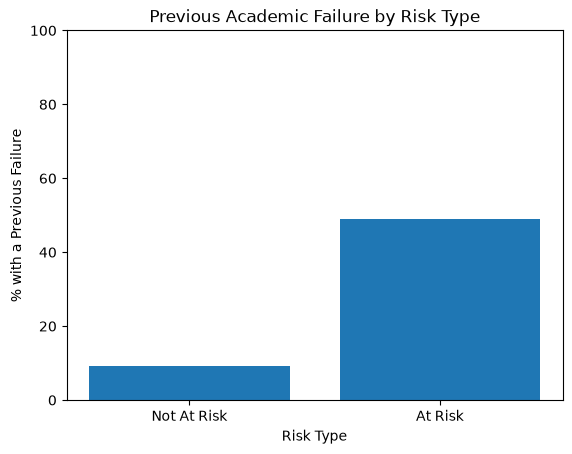

In [20]:
riskType=["Not At Risk", "At Risk"]

plt.bar(riskType,percFailiure)

plt.xlabel("Risk Type")
plt.ylabel("% with a Previous Failure")
plt.title("Previous Academic Failure by Risk Type")

plt.ylim(0, 100)

plt.savefig("../outputs/figures/4-risk_type_previous_failiures.png")
plt.show()

This tells us that previous failiure is far more common in the at risk gategory, around 5 times as common. This makes failiures look potentially useful for our early warning experiment

# Figure 5- Absences

In [21]:
#Mean
dfCsv.groupby("at_risk")["absences"].mean()

at_risk
0    3.486339
1    4.610000
Name: absences, dtype: float64

In [22]:
#Median
dfCsv.groupby("at_risk")["absences"].median()

at_risk
0    2.0
1    2.5
Name: absences, dtype: float64

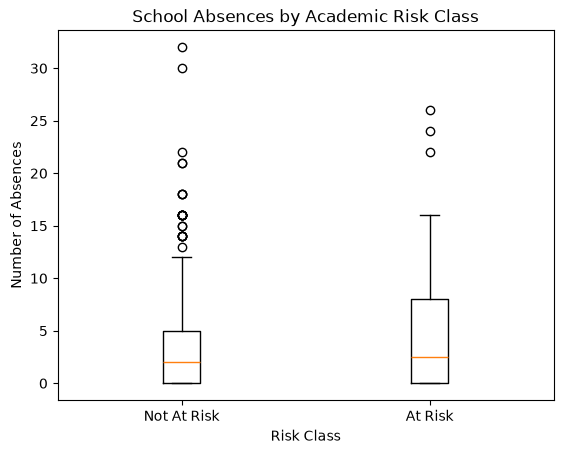

In [23]:
#BOXPLOT 
absencesNoRisk= dfCsv[dfCsv["at_risk"] ==0]["absences"]

absencesRisk= dfCsv[dfCsv["at_risk"] ==1]["absences"]

plt.boxplot(
    [absencesNoRisk, absencesRisk],
    tick_labels=["Not At Risk", "At Risk"]
)

plt.xlabel("Risk Class")
plt.ylabel("Number of Absences")
plt.title("School Absences by Academic Risk Class")

plt.savefig("../outputs/figures/5-absences_by_risk_boxplot.png")
plt.show()

At-risk students have slightly more absences on average

# Figure 6 - Performance change

How does a student's performance change between G1 and G2?

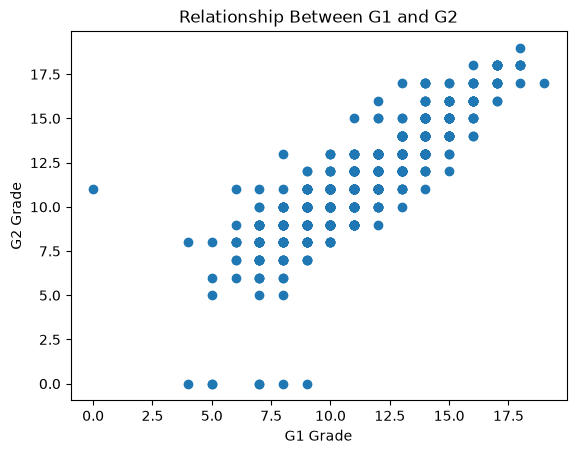

In [24]:
#Scatter Graph
#G1 x pos, G2 y pos
plt.scatter(dfCsv["G1"], dfCsv["G2"])

plt.xlabel("G1 Grade")
plt.ylabel("G2 Grade")
plt.title("Relationship Between G1 and G2")

plt.savefig( "../outputs/figures/6-g1_g2_scatterplot.png",)

plt.show()

In [25]:
#calculate correlation between G1 and G2
g1g2Correlation= dfCsv["G1"].corr(dfCsv["G2"])
g1g2Correlation
round(g1g2Correlation, 3)

np.float64(0.865)

A correlation of 0.865 show that students that score high in G1 generally  score highly in G2 and students with lower G1 generally have lower G2.

# Figure 7- What percentage of each risk group actually declined from G1 to G2?

In [26]:
#new column for grade difference between G1 and G2
dfCsv["grade_change"]= dfCsv["G2"]-dfCsv["G1"]
dfCsv[["G1","G2","grade_change"]].head()

,G1,G2,grade_change
0,0,11,11
1,9,11,2
2,12,13,1
3,14,14,0
4,11,13,2


In [27]:
#mean,median grade change for each risk type
dfCsv.groupby("at_risk")["grade_change"].agg(["mean","median"])

,mean,median
at_risk,,
0,0.247723,0.0
1,-0.250000,0.0


In [28]:
#grade_change< 0 = 1 =declined
#grade_change>=0 = 0 =no decline

dfCsv["declined"] = (dfCsv["grade_change"] <0).astype(int)

#percentage who declined for each risk group
declinePerc= dfCsv.groupby("at_risk")["declined"].mean()*100
declinePerc.round(2)

at_risk
0    27.69
1    35.00
Name: declined, dtype: float64

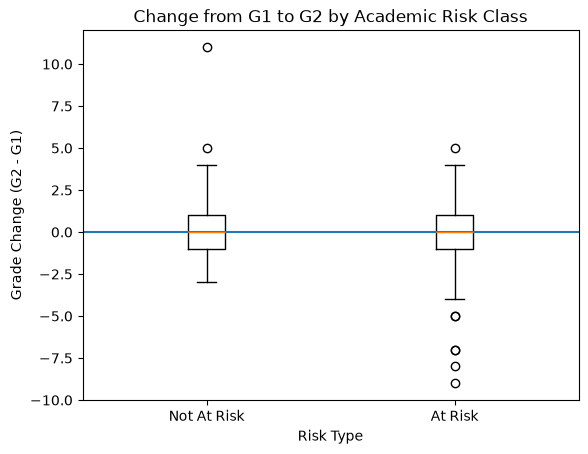

In [29]:
not_at_risk_change = dfCsv[dfCsv["at_risk"] == 0]["grade_change"]

at_risk_change = dfCsv[dfCsv["at_risk"] == 1]["grade_change"]

plt.boxplot(
    [not_at_risk_change, at_risk_change],
    tick_labels=["Not At Risk", "At Risk"]
)

plt.xlabel("Risk Type")
plt.ylabel("Grade Change (G2 - G1)")
plt.title("Change from G1 to G2 by Academic Risk Class")

#horizontal line at y=0- indicate no change
plt.axhline(0)
plt.savefig("../outputs/figures/7-grade_change_by_risk_boxplot.png")

plt.show()

one Not At Risk student improved massively, about +11
several At Risk students declined substantially, around −5 to −9

This tells us Grade change may contain some useful information, but it doesn't separate  risk groups nearly as strongly as G1, G2 or previous failures.

# Figure 8 - Final EDA summary 

In [30]:
#EDA summary table

eda_summary= pd.DataFrame({
    "Feature": [
        "G1 median",
        "G2 median",
        "Previous failure (%)",
        "Mean absences",
        "Grade decline (%)"
    ],

    "Not At Risk": [
        dfCsv[dfCsv["at_risk"] ==0]["G1"].median(),
        dfCsv[dfCsv["at_risk"] ==0]["G2"].median(),
        dfCsv[dfCsv["at_risk"] ==0]["prev_failure"].mean() * 100,
        dfCsv[dfCsv["at_risk"] ==0]["absences"].mean(),
        dfCsv[dfCsv["at_risk"] ==0]["declined"].mean() * 100
    ],

    "At Risk": [
        dfCsv[dfCsv["at_risk"] ==1]["G1"].median(),
        dfCsv[dfCsv["at_risk"] ==1]["G2"].median(),
        dfCsv[dfCsv["at_risk"] ==1]["prev_failure"].mean()*100,
        dfCsv[dfCsv["at_risk"] ==1]["absences"].mean(),
        dfCsv[dfCsv["at_risk"] ==1]["declined"].mean()*100
    ],

    "Initial observation": [
        "Strong difference",
        "Strong difference",
        "Strong difference",
        "Smaller difference",
        "Smaller difference"
    ]
})

eda_summary.round(2)

,Feature,Not At Risk,At Risk,Initial observation
0,G1 median,12.00,8.00,Strong difference
1,G2 median,12.00,8.00,Strong difference
2,Previous failure (%),9.29,49.00,Strong difference
3,Mean absences,3.49,4.61,Smaller difference
4,Grade decline (%),27.69,35.00,Smaller difference


grade_average = overall level of academic performance
grade_change = whether performance improved or declined

In [31]:
#create average assessment grade colomn (g1+g2)/2
dfCsv["grade_average"]=(dfCsv["G1"] +dfCsv["G2"])/2
dfCsv[["G1", "G2", "grade_average", "grade_change"]].head()

,G1,G2,grade_average,grade_change
0,0,11,5.5,11
1,9,11,10.0,2
2,12,13,12.5,1
3,14,14,14.0,0
4,11,13,12.0,2


## Experiment 1
Can we identify AtRisk students using only previous failures and attendance?

In [32]:
experiment1 =dfCsv[["failures","absences", "at_risk"]].copy()
experiment1.head()

,failures,absences,at_risk
0,0,4,0
1,0,2,0
2,0,6,0
3,0,0,0
4,0,0,0


## Experiment 2A
Can we identify AtRisk students better if we know actual G1 and G2 assessment grades? (if yes, shows earlier academic performance information is useful for predicting)

In [33]:
experiment2a =dfCsv[["failures","absences", "G1","G2", "at_risk"]].copy()
experiment2a.head()

,failures,absences,G1,G2,at_risk
0,0,4,0,11,0
1,0,2,9,11,0
2,0,6,12,13,0
3,0,0,14,14,0
4,0,0,11,13,0


## Experiment 2B
Is it better to represent assessment history using overall average and change in performance, or giving the model G1 and G2 directly?

In [34]:
experiment2b = dfCsv[["prev_failure","absences",
                       "grade_average","grade_change","at_risk"]
                    ].copy()

In [35]:
#debug check (all colomns still there?)
print("Experiment 1 shape:", experiment1.shape)
print("Experiment 2A shape:", experiment2a.shape)
print("Experiment 2B shape:", experiment2b.shape)


Experiment 1 shape: (649, 3)
Experiment 2A shape: (649, 5)
Experiment 2B shape: (649, 5)


## ML Link
Train/test split- model learns from one group and proves whether it correctly predicts risk on different group from dataset which it has not seen before.


In [36]:
from sklearn.model_selection import train_test_split

In [37]:
#x1-innput info model will use to predict if student is at risk or not
X1 =experiment1[["failures","absences"]]
#y1- target variable, if student is at risk or not
y1 =experiment1["at_risk"]

#train/test split
X1_train,X1_test,y1_train,y1_test =train_test_split(
    #failures, absences of students that model will learn from
    X1,
    #real atrisk answers for those same students
    y1,
    test_size=0.20,
    #keep random split same every time run - reproducibility
    random_state=42,
    #roughly same proportion of risk/no risk students in train and test sets
    stratify=y1
)

#check shapes
print("Experiment 1 X train:", X1_train.shape)
print("Experiment 1 X test:", X1_test.shape)
print("Experiment 1 y train:", y1_train.shape)
print("Experiment 1 y test:", y1_test.shape)

#check class balance
print("Experiment 1 Training At Risk %:", round(y1_train.mean()*100,2))
print("Experiment 1 Testing At Risk %:", round(y1_test.mean()*100,2))

Experiment 1 X train: (519, 2)
Experiment 1 X test: (130, 2)
Experiment 1 y train: (519,)
Experiment 1 y test: (130,)
Experiment 1 Training At Risk %: 15.41
Experiment 1 Testing At Risk %: 15.38


In [38]:
#x2a-innput info model will use to predict if student is at risk or not
X2a =experiment2a[["failures","absences","G1","G2"]]
#y2a- target variable, if student is at risk or not
y2a =experiment2a["at_risk"]

#train/test split
X2a_train,X2a_test,y2a_train,y2a_test =train_test_split(
    #failures, absences, G1, G2 of students that model will learn from
    X2a,
    #real atRisk answers for those same students
    y2a,
    test_size=0.20,
    #keep random split same every time run - reproducibility
    random_state=42,
    #roughly same proportion of risk/no risk students in train and test sets
    stratify=y2a
)

#check shapes
print("Experiment 2A X train:", X2a_train.shape)
print("Experiment 2A X test:", X2a_test.shape)
print("Experiment 2A y train:", y2a_train.shape)
print("Experiment 2A y test:", y2a_test.shape)

#check class balance
print("Experiment 2A Training At Risk %:", round(y2a_train.mean()*100,2))
print("Experiment 2A Testing At Risk %:", round(y2a_test.mean()*100,2))

Experiment 2A X train: (519, 4)
Experiment 2A X test: (130, 4)
Experiment 2A y train: (519,)
Experiment 2A y test: (130,)
Experiment 2A Training At Risk %: 15.41
Experiment 2A Testing At Risk %: 15.38


In [39]:
#x2b-innput info model will use to predict if student is at risk or not
X2b =experiment2b[["prev_failure","absences","grade_average","grade_change"]]
#y2b- target variable, if student is at risk or not
y2b =experiment2b["at_risk"]

#train/test split
X2b_train,X2b_test,y2b_train,y2b_test =train_test_split(
    #prev_failure, absences, grade_average, grade_change of students that model will learn from
    X2b,
    #real atrisk answers for those same students
    y2b,
    test_size=0.20,
    #keep random split same every time run - reproducibility
    random_state=42,
    #roughly same proportion of risk/no risk students in train and test sets
    stratify=y2b
)

#check shapes
print("Experiment 2B X train:", X2b_train.shape)
print("Experiment 2B X test:", X2b_test.shape)
print("Experiment 2B y train:", y2b_train.shape)
print("Experiment 2B y test:", y2b_test.shape)

#check class balance
print("Experiment 2B Training At Risk %:", round(y2b_train.mean()*100,2))
print("Experiment 2B Testing At Risk %:", round(y2b_test.mean()*100,2))

Experiment 2B X train: (519, 4)
Experiment 2B X test: (130, 4)
Experiment 2B y train: (519,)
Experiment 2B y test: (130,)
Experiment 2B Training At Risk %: 15.41
Experiment 2B Testing At Risk %: 15.38


# Baseline Model

The baseline model will predict the majority class for every student. This provides minimum benchmark that the trained models should beat. Don't need to test on experiment 2 as it will predict not risk regardless of headers.

In [40]:
#imports
from sklearn.dummy import DummyClassifier
import numpy as np
from sklearn.metrics import accuracy_score

In [41]:
#find which y value is most frequent and use that as prediction for all test data
#should be 0 (mst students not at risk)
baseline_model = DummyClassifier(strategy="most_frequent")

In [42]:
#not really learning from patterns in absences and failiures. 
#will always predict most frequent class for all students
baseline_model.fit(X1_train, y1_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.85,0.15]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](2,)","['failures','absences']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,2
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [43]:
baseline_predictions =baseline_model.predict(X1_test)

In [44]:
#check the predictions
print("Number of predictions:",len(baseline_predictions))
print("Prediction values and counts:",np.unique(baseline_predictions,return_counts=True))

Number of predictions: 130
Prediction values and counts: (array([0]), array([130]))


In [45]:
#calculate accuracy
baseline_accuracy =accuracy_score(y1_test,baseline_predictions)
print("Baseline accuracy:",baseline_accuracy)

Baseline accuracy: 0.8461538461538461


Although the accuracy is high, being around 85%. The number of correct at risk predictions is 0.

In [46]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [47]:
#accuracy
baseline_accuracy =accuracy_score(y1_test,baseline_predictions)
print("Baseline accuracy:",round(baseline_accuracy*100,2),"%")

Baseline accuracy: 84.62 %


In [48]:
#precision
#zero_division= if no positive predictions,reprort 0 instead of error
baseline_precision =precision_score(y1_test,baseline_predictions, zero_division=0)
print("Baseline precision:",round(baseline_precision*100,2),"%")

Baseline precision: 0.0 %


In [49]:
#recall
baseline_recall =recall_score(y1_test,baseline_predictions)
print("Baseline recall:",round(baseline_recall*100,2),"%")

Baseline recall: 0.0 %


In [50]:
#f1 score
baseline_f1 =f1_score(y1_test,baseline_predictions, zero_division=0)
print("Baseline f1 score:",round(baseline_f1*100,2),"%")

Baseline f1 score: 0.0 %


In [51]:
#confusion matrix
baseline_confusion_matrix =confusion_matrix(y1_test,baseline_predictions)
print("Baseline confusion matrix:")
print(baseline_confusion_matrix)



Baseline confusion matrix:
[[110   0]
 [ 20   0]]


# Logistic Regression- Experiment 1

Can early-warning indicators identify AtRisk students without using G1 or G2?

In [52]:
#imports
from sklearn.linear_model import LogisticRegression

In [53]:
#create log regression model and train
logistic_exp1= LogisticRegression()
#train with experiment 1 data (failures, absences) 
logistic_exp1.fit(X1_train, y1_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [54]:
#predict on test data
logistic_exp1_predictions = logistic_exp1.predict(X1_test)

#check no of predictions and values
print("Number of predictions:",len(logistic_exp1_predictions))

#check number of students predicted at risk 1 & not at risk 0
print("Prediction values and counts:",np.unique(logistic_exp1_predictions,return_counts=True))


Number of predictions: 130
Prediction values and counts: (array([0, 1]), array([128,   2]))


In [55]:
#accuracy
logistic_exp1_accuracy =accuracy_score(y1_test,logistic_exp1_predictions)
print("Experiment 1 accuracy:",round(logistic_exp1_accuracy*100,2),"%")

#precision
#zero_division= if no positive predictions,report 0 instead of warning
logistic_exp1_precision  =precision_score(y1_test,logistic_exp1_predictions, zero_division=0)
print("Experiment 1 precision:",round(logistic_exp1_precision *100,2),"%")

#recall
logistic_exp1_recall  =recall_score(y1_test,logistic_exp1_predictions)
print("Experiment 1 recall:",round(logistic_exp1_recall *100,2),"%")

#f1 score
logistic_exp1_f1  =f1_score(y1_test,logistic_exp1_predictions, zero_division=0)
print("Experiment 1 f1 score:",round(logistic_exp1_f1 *100,2),"%")

#confusion matrix
logistic_exp1_confusion  =confusion_matrix(y1_test,logistic_exp1_predictions)
print("Experiment 1 confusion matrix:")
print(logistic_exp1_confusion )



Experiment 1 accuracy: 83.08 %
Experiment 1 precision: 0.0 %
Experiment 1 recall: 0.0 %
Experiment 1 f1 score: 0.0 %
Experiment 1 confusion matrix:
[[108   2]
 [ 20   0]]


# Logistic Regression - Experiment 2A

In [56]:
#create log regression model and train
logistic_exp2a= LogisticRegression()
#train with experiment 2a data (failures, absences, G1 , G2) 
logistic_exp2a.fit(X2a_train,y2a_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [57]:
#predict on test data
logistic_exp2a_predictions= logistic_exp2a.predict(X2a_test)

#check no of predictions and values
print("Number of predictions:",len(logistic_exp2a_predictions))

#check number of students predicted at risk 1 & not at risk 0
print("Prediction values and counts:",np.unique(logistic_exp2a_predictions,return_counts=True))


Number of predictions: 130
Prediction values and counts: (array([0, 1]), array([108,  22]))


In [58]:
#accuracy
logistic_exp2a_accuracy= accuracy_score(y2a_test,logistic_exp2a_predictions)
print("Experiment 2A accuracy:",round(logistic_exp2a_accuracy*100,2),"%")

#precision
#zero_division= if no positive predictions,report 0 instead of warning
logistic_exp2a_precision= precision_score(y2a_test,logistic_exp2a_predictions,zero_division=0)
print("Experiment 2A precision:",round(logistic_exp2a_precision*100,2),"%")

#recall
logistic_exp2a_recall= recall_score(y2a_test,logistic_exp2a_predictions)
print("Experiment 2A recall:",round(logistic_exp2a_recall*100,2),"%")

#f1 score
logistic_exp2a_f1= f1_score(y2a_test,logistic_exp2a_predictions,zero_division=0)
print("Experiment 2A f1 score:",round(logistic_exp2a_f1*100,2),"%")

#confusion matrix
logistic_exp2a_confusion= confusion_matrix(y2a_test,logistic_exp2a_predictions)
print("Experiment 2A confusion matrix:")
print(logistic_exp2a_confusion)



Experiment 2A accuracy: 92.31 %
Experiment 2A precision: 72.73 %
Experiment 2A recall: 80.0 %
Experiment 2A f1 score: 76.19 %
Experiment 2A confusion matrix:
[[104   6]
 [  4  16]]


# Logistic Regression - Experiment 2B

In [59]:
#create log regression model and train
logistic_exp2b= LogisticRegression()
#train with experiment 2b data (prev_failure, absences, grade_average, grade_change) 
logistic_exp2b.fit(X2b_train,y2b_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [60]:
#predict on test data
logistic_exp2b_predictions= logistic_exp2b.predict(X2b_test)

#check no of predictions and values
print("Number of predictions:",len(logistic_exp2b_predictions))

#check number of students predicted at risk 1 & not at risk 0
print("Prediction values and counts:",np.unique(logistic_exp2b_predictions,return_counts=True))


Number of predictions: 130
Prediction values and counts: (array([0, 1]), array([107,  23]))


In [61]:
#accuracy
logistic_exp2b_accuracy= accuracy_score(y2b_test,logistic_exp2b_predictions)
print("Experiment 2B accuracy:",round(logistic_exp2b_accuracy*100,2),"%")

#precision
#zero_division= if no positive predictions,report 0 instead of warning
logistic_exp2b_precision= precision_score(y2b_test,logistic_exp2b_predictions,zero_division=0)
print("Experiment 2B precision:",round(logistic_exp2b_precision*100,2),"%")

#recall
logistic_exp2b_recall= recall_score(y2b_test,logistic_exp2b_predictions)
print("Experiment 2B recall:",round(logistic_exp2b_recall*100,2),"%")

#f1 score
logistic_exp2b_f1= f1_score(y2b_test,logistic_exp2b_predictions,zero_division=0)
print("Experiment 2B f1 score:",round(logistic_exp2b_f1*100,2),"%")

#confusion matrix
logistic_exp2b_confusion= confusion_matrix(y2b_test,logistic_exp2b_predictions)
print("Experiment 2B confusion matrix:")
print(logistic_exp2b_confusion)



Experiment 2B accuracy: 93.08 %
Experiment 2B precision: 73.91 %
Experiment 2B recall: 85.0 %
Experiment 2B f1 score: 79.07 %
Experiment 2B confusion matrix:
[[104   6]
 [  3  17]]


# Logistic Regression- Comparison Table & Confusion Matrix

In [62]:
logistic_comparison= pd.DataFrame({
    "Model / Experiment":[
        "Majority Baseline",
        "Logistic Regression - Experiment 1",
        "Logistic Regression - Experiment 2A",
        "Logistic Regression - Experiment 2B"
    ],

    "Accuracy":[
        baseline_accuracy,
        logistic_exp1_accuracy,
        logistic_exp2a_accuracy,
        logistic_exp2b_accuracy
    ],

    "Precision":[
        baseline_precision,
        logistic_exp1_precision,
        logistic_exp2a_precision,
        logistic_exp2b_precision
    ],

    "Recall":[
        baseline_recall,
        logistic_exp1_recall,
        logistic_exp2a_recall,
        logistic_exp2b_recall
    ],

    "F1":[
        baseline_f1,
        logistic_exp1_f1,
        logistic_exp2a_f1,
        logistic_exp2b_f1
    ]
})

logistic_comparison.round(4)

#save comparison table to csv
logistic_comparison.to_csv("../outputs/logistic_comparison.csv", index=False)

From the above, it shows that Experiment 1 (which only used failiures and adbsences) failed to identify students at risk despite having high accuracy.
 
 Adding in G1 and G2 in Experiment 2A improved the models performance. With 80% recall and 76.19% F1.
 
 Experiment 2B produced the best result from this train/test split. With 85% rrecall and 79% F1.
 
 However the difference between 2A and 2B is very small and will need further validation. (meaning 2B is best on this one split, but it isnt yet established that it is consistently better than 2A)

## Confusion Matrix

### Experiment 1

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay

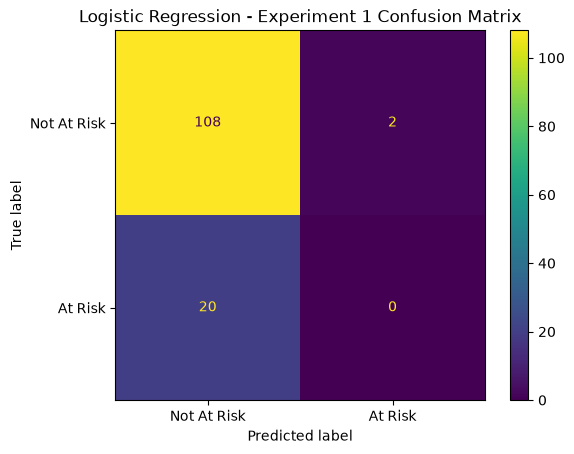

In [64]:
#confusion matrix visual -logistic regression experiment 1

fig,ax= plt.subplots()

confusion_exp1= ConfusionMatrixDisplay(
    confusion_matrix=logistic_exp1_confusion,
    display_labels=["Not At Risk","At Risk"]
)

confusion_exp1.plot(ax=ax)

plt.title("Logistic Regression - Experiment 1 Confusion Matrix")
plt.savefig("../outputs/figures/9-logistic_exp1_confusion_matrix.png")
plt.show()

### Experiment 2A

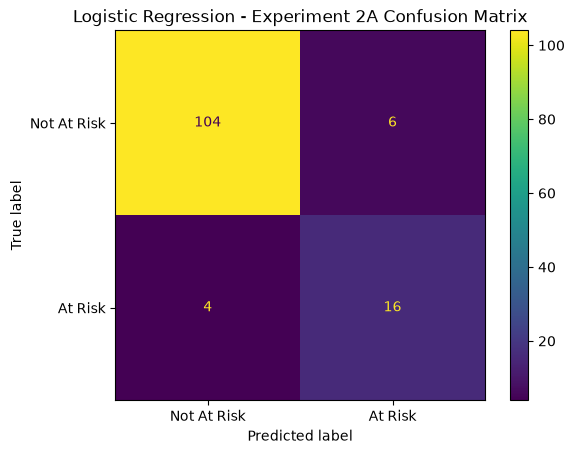

In [65]:
#confusion matrix visual -logistic regression experiment 2a

fig,ax= plt.subplots()

confusion_exp2a= ConfusionMatrixDisplay(
    confusion_matrix=logistic_exp2a_confusion,
    display_labels=["Not At Risk","At Risk"]
)

confusion_exp2a.plot(ax=ax)

plt.title("Logistic Regression - Experiment 2A Confusion Matrix")
plt.savefig("../outputs/figures/10-logistic_exp2a_confusion_matrix.png")
plt.show()

### Experiment 2B

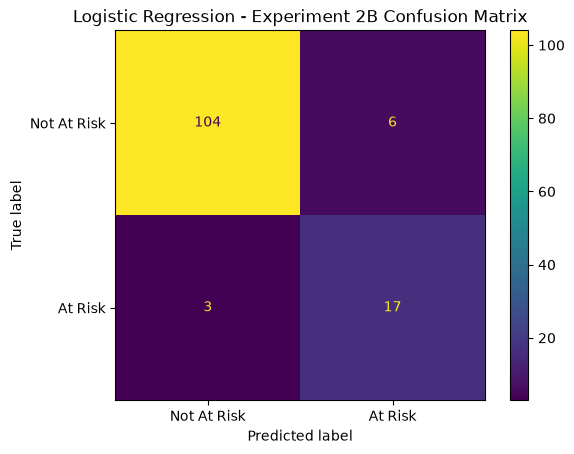

In [66]:
#confusion matrix visual -logistic regression experiment 2b

fig,ax= plt.subplots()

confusion_exp2b= ConfusionMatrixDisplay(
    confusion_matrix=logistic_exp2b_confusion,
    display_labels=["Not At Risk","At Risk"]
)

confusion_exp2b.plot(ax=ax)

plt.title("Logistic Regression - Experiment 2B Confusion Matrix")
plt.savefig("../outputs/figures/11-logistic_exp2b_confusion_matrix.png")
plt.show()

# Decision Trees

Rather than linear regression, decision tress can capture non-linear relationships (e.g. between absences combined with previous failure)

In [67]:
#imports
from sklearn.tree import DecisionTreeClassifier

# Decision Tree - Experiment 1

In [68]:
#create decision tree
tree_exp1= DecisionTreeClassifier(random_state=42)

#train model with experiment 1 data (failures, absences)
tree_exp1.fit(X1_train, y1_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [69]:
# #predict on test data
tree_exp1_predictions= tree_exp1.predict(X1_test)

#check no of predictions and values
print("Number of predictions:",len(tree_exp1_predictions))

#check number of students predicted at risk 1 & not at risk 0
print("Prediction values and counts:",np.unique(tree_exp1_predictions,return_counts=True))

Number of predictions: 130
Prediction values and counts: (array([0, 1]), array([120,  10]))


In [70]:
#accuracy
tree_exp1_accuracy= accuracy_score(y1_test,tree_exp1_predictions)
print("Decision Tree Experiment 1 accuracy:",round(tree_exp1_accuracy*100,2),"%")

#precision
#zero_division= if no positive predictions,report 0 instead of warning
tree_exp1_precision= precision_score(y1_test,tree_exp1_predictions,zero_division=0)
print("Decision Tree Experiment 1 precision:",round(tree_exp1_precision*100,2),"%")

#recall
tree_exp1_recall= recall_score(y1_test,tree_exp1_predictions)
print("Decision Tree Experiment 1 recall:",round(tree_exp1_recall*100,2),"%")

#f1 score
tree_exp1_f1= f1_score(y1_test,tree_exp1_predictions,zero_division=0)
print("Decision Tree Experiment 1 f1 score:",round(tree_exp1_f1*100,2),"%")

#confusion matrix
tree_exp1_confusion= confusion_matrix(y1_test,tree_exp1_predictions)
print("Decision Tree Experiment 1 confusion matrix:")
print(tree_exp1_confusion)

Decision Tree Experiment 1 accuracy: 84.62 %
Decision Tree Experiment 1 precision: 50.0 %
Decision Tree Experiment 1 recall: 25.0 %
Decision Tree Experiment 1 f1 score: 33.33 %
Decision Tree Experiment 1 confusion matrix:
[[105   5]
 [ 15   5]]


# Decision Tree - Experiment 2a

In [71]:
#create decision tree
tree_exp2a= DecisionTreeClassifier(random_state=42)

#train model with experiment 2a data (failures, absences,g1,g2)
tree_exp2a.fit(X2a_train, y2a_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [72]:
# #predict on test data
tree_exp2a_predictions= tree_exp2a.predict(X2a_test)

#check no of predictions and values
print("Number of predictions:",len(tree_exp2a_predictions))

#check number of students predicted at risk 1 & not at risk 0
print("Prediction values and counts:",np.unique(tree_exp2a_predictions,return_counts=True))

Number of predictions: 130
Prediction values and counts: (array([0, 1]), array([110,  20]))


In [73]:
#accuracy
tree_exp2a_accuracy= accuracy_score(y2a_test,tree_exp2a_predictions)
print("Decision Tree Experiment 2a accuracy:",round(tree_exp2a_accuracy*100,2),"%")

#precision
#zero_division= if no positive predictions,report 0 instead of warning
tree_exp2a_precision= precision_score(y2a_test,tree_exp2a_predictions,zero_division=0)
print("Decision Tree Experiment 2a precision:",round(tree_exp2a_precision*100,2),"%")

#recall
tree_exp2a_recall= recall_score(y2a_test,tree_exp2a_predictions)
print("Decision Tree Experiment 2a recall:",round(tree_exp2a_recall*100,2),"%")

#f1 score
tree_exp2a_f1= f1_score(y2a_test,tree_exp2a_predictions,zero_division=0)
print("Decision Tree Experiment 2a f1 score:",round(tree_exp2a_f1*100,2),"%")

#confusion matrix
tree_exp2a_confusion= confusion_matrix(y2a_test,tree_exp2a_predictions)
print("Decision Tree Experiment 2a confusion matrix:")
print(tree_exp2a_confusion)

Decision Tree Experiment 2a accuracy: 89.23 %
Decision Tree Experiment 2a precision: 65.0 %
Decision Tree Experiment 2a recall: 65.0 %
Decision Tree Experiment 2a f1 score: 65.0 %
Decision Tree Experiment 2a confusion matrix:
[[103   7]
 [  7  13]]


# Decision Tree - Experiment 2B

In [74]:
#create decision tree
tree_exp2b= DecisionTreeClassifier(random_state=42)

#train model with experiment 2b data (prev_failure,absences,grade_average,grade_change)
tree_exp2b.fit(X2b_train, y2b_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [75]:
# #predict on test data
tree_exp2b_predictions= tree_exp2b.predict(X2b_test)

#check no of predictions and values
print("Number of predictions:",len(tree_exp2b_predictions))

#check number of students predicted at risk 1 & not at risk 0
print("Prediction values and counts:",np.unique(tree_exp2b_predictions,return_counts=True))

Number of predictions: 130
Prediction values and counts: (array([0, 1]), array([110,  20]))


In [76]:
#accuracy
tree_exp2b_accuracy= accuracy_score(y2b_test,tree_exp2b_predictions)
print("Decision Tree Experiment 2b accuracy:",round(tree_exp2b_accuracy*100,2),"%")

#precision
#zero_division= if no positive predictions,report 0 instead of warning
tree_exp2b_precision= precision_score(y2b_test,tree_exp2b_predictions,zero_division=0)
print("Decision Tree Experiment 2b precision:",round(tree_exp2b_precision*100,2),"%")

#recall
tree_exp2b_recall= recall_score(y2b_test,tree_exp2b_predictions)
print("Decision Tree Experiment 2b recall:",round(tree_exp2b_recall*100,2),"%")

#f1 score
tree_exp2b_f1= f1_score(y2b_test,tree_exp2b_predictions,zero_division=0)
print("Decision Tree Experiment 2b f1 score:",round(tree_exp2b_f1*100,2),"%")

#confusion matrix
tree_exp2b_confusion= confusion_matrix(y2b_test,tree_exp2b_predictions)
print("Decision Tree Experiment 2b confusion matrix:")
print(tree_exp2b_confusion)

Decision Tree Experiment 2b accuracy: 89.23 %
Decision Tree Experiment 2b precision: 65.0 %
Decision Tree Experiment 2b recall: 65.0 %
Decision Tree Experiment 2b f1 score: 65.0 %
Decision Tree Experiment 2b confusion matrix:
[[103   7]
 [  7  13]]


# Decision Tree comparison table

In [77]:
#decision tree comparison table

decision_tree_comparison= pd.DataFrame({
    "Model / Experiment":[
        "Decision Tree - Experiment 1",
        "Decision Tree - Experiment 2A",
        "Decision Tree - Experiment 2B"
    ],

    "Accuracy":[
        tree_exp1_accuracy,
        tree_exp2a_accuracy,
        tree_exp2b_accuracy
    ],

    "Precision":[
        tree_exp1_precision,
        tree_exp2a_precision,
        tree_exp2b_precision
    ],

    "Recall":[
        tree_exp1_recall,
        tree_exp2a_recall,
        tree_exp2b_recall
    ],

    "F1":[
        tree_exp1_f1,
        tree_exp2a_f1,
        tree_exp2b_f1
    ]
})

decision_tree_comparison.round(4)

,Model / Experiment,Accuracy,Precision,Recall,F1
0,Decision Tree - Experiment 1,0.8462,0.50,0.25,0.3333
1,Decision Tree - Experiment 2A,0.8923,0.65,0.65,0.6500
2,Decision Tree - Experiment 2B,0.8923,0.65,0.65,0.6500


Decision tree experiment 1 improved in the recall compared with linear regression experiment 1, but it still missed most of the at risk students.

Adding assessment information in Experiments 2A and 2B substantially improved decision trees performance. They produced identical results, which is suggesting that they produced identical predictive performance on this test split.

### decision tree experiment 2a training predictions

In [78]:
tree_exp2a_train_predictions= tree_exp2a.predict(X2a_train)

#training accuracy
tree_exp2a_train_accuracy= accuracy_score(y2a_train,tree_exp2a_train_predictions)

print("Decision Tree Experiment 2A training accuracy:",round(tree_exp2a_train_accuracy*100,2),"%")
print("Decision Tree Experiment 2A test accuracy:",round(tree_exp2a_accuracy*100,2),"%")

Decision Tree Experiment 2A training accuracy: 98.65 %
Decision Tree Experiment 2A test accuracy: 89.23 %


### decision tree experiment 2b training predictions

In [79]:
tree_exp2b_train_predictions= tree_exp2b.predict(X2b_train)

#training accuracy
tree_exp2b_train_accuracy= accuracy_score(y2b_train,tree_exp2b_train_predictions)

print("Decision Tree Experiment 2B training accuracy:",round(tree_exp2b_train_accuracy*100,2),"%")
print("Decision Tree Experiment 2B test accuracy:",round(tree_exp2b_accuracy*100,2),"%")

Decision Tree Experiment 2B training accuracy: 98.46 %
Decision Tree Experiment 2B test accuracy: 89.23 %


This shows the unrestricted decision trees are overfitting

# Random Forest - Experiment 1

In [80]:
from sklearn.ensemble import RandomForestClassifier

In [81]:
#create random forest model 
forest_exp1= RandomForestClassifier(random_state=42)

#train model using experiment 1 training data
forest_exp1.fit(X1_train,y1_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [82]:
#predict on test data
forest_exp1_predictions= forest_exp1.predict(X1_test)

#check no of predictions and values
print("Number of predictions:",len(forest_exp1_predictions))

#check number of students predicted at risk 1 & not at risk 0
print("Prediction values and counts:",np.unique(forest_exp1_predictions,return_counts=True))


Number of predictions: 130
Prediction values and counts: (array([0, 1]), array([119,  11]))


In [83]:
#accuracy
forest_exp1_accuracy= accuracy_score(y1_test,forest_exp1_predictions)
print("Random Forest Experiment 1 accuracy:",round(forest_exp1_accuracy*100,2),"%")

#precision
#zero_division= if no positive predictions,report 0 instead of warning
forest_exp1_precision= precision_score(y1_test,forest_exp1_predictions,zero_division=0)
print("Random Forest Experiment 1 precision:",round(forest_exp1_precision*100,2),"%")

#recall
forest_exp1_recall= recall_score(y1_test,forest_exp1_predictions)
print("Random Forest Experiment 1 recall:",round(forest_exp1_recall*100,2),"%")

#f1 score
forest_exp1_f1= f1_score(y1_test,forest_exp1_predictions,zero_division=0)
print("Random Forest Experiment 1 f1 score:",round(forest_exp1_f1*100,2),"%")

#confusion matrix
forest_exp1_confusion= confusion_matrix(y1_test,forest_exp1_predictions)
print("Random Forest Experiment 1 confusion matrix:")
print(forest_exp1_confusion)

Random Forest Experiment 1 accuracy: 83.85 %
Random Forest Experiment 1 precision: 45.45 %
Random Forest Experiment 1 recall: 25.0 %
Random Forest Experiment 1 f1 score: 32.26 %
Random Forest Experiment 1 confusion matrix:
[[104   6]
 [ 15   5]]


# Random Forest - Experiment 2A

In [84]:
#create random forest model 
forest_exp2a= RandomForestClassifier(random_state=42)

#train model using experiment 2a training data
forest_exp2a.fit(X2a_train,y2a_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [85]:
#predict on test data
forest_exp2a_predictions= forest_exp2a.predict(X2a_test)

#check no of predictions and values
print("Number of predictions:",len(forest_exp2a_predictions))

#check number of students predicted at risk 1 & not at risk 0
print("Prediction values and counts:",np.unique(forest_exp2a_predictions,return_counts=True))


Number of predictions: 130
Prediction values and counts: (array([0, 1]), array([110,  20]))


In [86]:
#accuracy
forest_exp2a_accuracy= accuracy_score(y2a_test,forest_exp2a_predictions)
print("Random Forest Experiment 2a accuracy:",round(forest_exp2a_accuracy*100,2),"%")

#precision
#zero_division= if no positive predictions,report 0 instead of warning
forest_exp2a_precision= precision_score(y2a_test,forest_exp2a_predictions,zero_division=0)
print("Random Forest Experiment 2a precision:",round(forest_exp2a_precision*100,2),"%")

#recall
forest_exp2a_recall= recall_score(y2a_test,forest_exp2a_predictions)
print("Random Forest Experiment 2a recall:",round(forest_exp2a_recall*100,2),"%")

#f1 score
forest_exp2a_f1= f1_score(y2a_test,forest_exp2a_predictions,zero_division=0)
print("Random Forest Experiment 2a f1 score:",round(forest_exp2a_f1*100,2),"%")

#confusion matrix
forest_exp2a_confusion= confusion_matrix(y2a_test,forest_exp2a_predictions)
print("Random Forest Experiment 2a confusion matrix:")
print(forest_exp2a_confusion)

Random Forest Experiment 2a accuracy: 89.23 %
Random Forest Experiment 2a precision: 65.0 %
Random Forest Experiment 2a recall: 65.0 %
Random Forest Experiment 2a f1 score: 65.0 %
Random Forest Experiment 2a confusion matrix:
[[103   7]
 [  7  13]]


# Random Forest - Experiment 2B

In [87]:
#create random forest model 
forest_exp2b= RandomForestClassifier(random_state=42)

#train model using experiment 2b training data
forest_exp2b.fit(X2b_train,y2b_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [88]:
#predict on test data
forest_exp2b_predictions= forest_exp2b.predict(X2b_test)

#check no of predictions and values
print("Number of predictions:",len(forest_exp2b_predictions))

#check number of students predicted at risk 1 & not at risk 0
print("Prediction values and counts:",np.unique(forest_exp2b_predictions,return_counts=True))


Number of predictions: 130
Prediction values and counts: (array([0, 1]), array([106,  24]))


In [89]:
#accuracy
forest_exp2b_accuracy= accuracy_score(y2b_test,forest_exp2b_predictions)
print("Random Forest Experiment 2b accuracy:",round(forest_exp2b_accuracy*100,2),"%")

#precision
#zero_division= if no positive predictions,report 0 instead of warning
forest_exp2b_precision= precision_score(y2b_test,forest_exp2b_predictions,zero_division=0)
print("Random Forest Experiment 2b precision:",round(forest_exp2b_precision*100,2),"%")

#recall
forest_exp2b_recall= recall_score(y2b_test,forest_exp2b_predictions)
print("Random Forest Experiment 2b recall:",round(forest_exp2b_recall*100,2),"%")

#f1 score
forest_exp2b_f1= f1_score(y2b_test,forest_exp2b_predictions,zero_division=0)
print("Random Forest Experiment 2b f1 score:",round(forest_exp2b_f1*100,2),"%")

#confusion matrix
forest_exp2b_confusion= confusion_matrix(y2b_test,forest_exp2b_predictions)
print("Random Forest Experiment 2b confusion matrix:")
print(forest_exp2b_confusion)

Random Forest Experiment 2b accuracy: 87.69 %
Random Forest Experiment 2b precision: 58.33 %
Random Forest Experiment 2b recall: 70.0 %
Random Forest Experiment 2b f1 score: 63.64 %
Random Forest Experiment 2b confusion matrix:
[[100  10]
 [  6  14]]


# Random Forest comparison table

In [90]:
random_forest_comparison= pd.DataFrame({
    "Model / Experiment":[
        "Random Forest - Experiment 1",
        "Random Forest - Experiment 2A",
        "Random Forest - Experiment 2B"
    ],

    "Accuracy":[
        forest_exp1_accuracy,
        forest_exp2a_accuracy,
        forest_exp2b_accuracy
    ],

    "Precision":[
        forest_exp1_precision,
        forest_exp2a_precision,
        forest_exp2b_precision
    ],

    "Recall":[
        forest_exp1_recall,
        forest_exp2a_recall,
        forest_exp2b_recall
    ],

    "F1":[
        forest_exp1_f1,
        forest_exp2a_f1,
        forest_exp2b_f1
    ]
})

random_forest_comparison.round(4)

,Model / Experiment,Accuracy,Precision,Recall,F1
0,Random Forest - Experiment 1,0.8385,0.4545,0.25,0.3226
1,Random Forest - Experiment 2A,0.8923,0.6500,0.65,0.6500
2,Random Forest - Experiment 2B,0.8769,0.5833,0.70,0.6364


Random forest experiment 1 only identified 25% of at risk student making it a weak outcome.
Adding in assessment information in Experiment 2A and 2B improved forest performance.
Experiment 2A achieved stronger overall precision and F1 score, while 2B achieved slightly higher recall but also produced more false posiive predictions.

# Master comparison table

In [94]:
#master model comparison table
model_comparison= pd.concat([logistic_comparison,decision_tree_comparison,random_forest_comparison],ignore_index=True)

#save master comparison table
model_comparison.to_csv("../outputs/results/model_comparison.csv",index=False)

#display table
model_comparison.round(4)

,Model / Experiment,Accuracy,Precision,Recall,F1
0,Majority Baseline,0.8462,0.0000,0.00,0.0000
1,Logistic Regression - Experiment 1,0.8308,0.0000,0.00,0.0000
2,Logistic Regression - Experiment 2A,0.9231,0.7273,0.80,0.7619
3,Logistic Regression - Experiment 2B,0.9308,0.7391,0.85,0.7907
4,Decision Tree - Experiment 1,0.8462,0.5000,0.25,0.3333
5,Decision Tree - Experiment 2A,0.8923,0.6500,0.65,0.6500
6,Decision Tree - Experiment 2B,0.8923,0.6500,0.65,0.6500
7,Random Forest - Experiment 1,0.8385,0.4545,0.25,0.3226
8,Random Forest - Experiment 2A,0.8923,0.6500,0.65,0.6500
9,Random Forest - Experiment 2B,0.8769,0.5833,0.70,0.6364


Experiment 1 is weak across all three algorithms.
Adding assessment information improves performance substantially.
Logistic Regression currently beats Decision Tree and Random Forest on this split.
Experiment 2B is slightly better than 2A for Logistic Regression, but we still need cross-validation before calling it genuinely superior.